# Costco Basket Size Prediction
## XGboost + SHAP model

  * This model was built to predict Costco members' holiday spending using prior behavior and membership characteristics.

In [ ]:
# Importing Libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor
import xgboost as xgb
import shap

from google.colab import files
import io

import matplotlib.pyplot as plt
import seaborn as sns

### Exploratory Data Analysis

* I created a synthetic dataset with 5,000 members and 14 features; such as: spending trends, visit frequency, department spending, tenure, and promo usage.

In [ ]:
# File picker dialog to select the file
uploaded = files.upload()

Saving Costco_simulated_data.csv to Costco_simulated_data (2).csv


In [ ]:
# Uploading the data
filename = list(uploaded.keys())[0]
costco = pd.read_csv(io.BytesIO(uploaded[filename]))

print(f"Successfully loaded '{filename}' into a DataFrame.")

Successfully loaded 'Costco_simulated_data (2).csv' into a DataFrame.


In [ ]:
# Looking at the first 5 rows of data
display(costco.head())

,member_ID,rolling_12mo_spend,rolling_12mo_visit,rolling_12mo_avg_basket,rolling_24mo_spend,pct_spend_grocery_consumables,pct_spend_pharmacy_health,pct_spend_home_hardware,pct_spend_auto_sporting,pct_spend_general_merch,member_tenure_years,return_rate,executive_flag,weekend_shopping_ratio,promo_usage_rate,holiday_spend
0,1,6180.845853,28,220.744495,8507.820429,0.140631,0.112712,0.304053,0.133253,0.309350,40.8,0.027323,1,0.696651,0.146200,1305.154465
1,2,3828.550871,19,201.502677,5151.039486,0.150085,0.111785,0.130013,0.289382,0.318735,35.8,0.070135,1,0.376764,0.316922,1624.176912
2,3,8010.783410,21,381.465877,12041.420198,0.200007,0.105754,0.193962,0.131856,0.368421,31.6,0.022134,1,0.268387,0.133382,2429.320173
3,4,5652.722854,18,314.040159,7250.010815,0.346491,0.071676,0.199436,0.075241,0.307156,31.2,0.009367,1,0.227840,0.198371,1914.838730
4,5,7650.925964,24,318.788582,10317.043832,0.141506,0.223282,0.105533,0.047519,0.482160,25.3,0.015895,1,0.351477,0.186348,2962.872901


In [ ]:
# Data structure
costco.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   member_ID                      5000 non-null   int64  
 1   rolling_12mo_spend             5000 non-null   float64
 2   rolling_12mo_visit             5000 non-null   int64  
 3   rolling_12mo_avg_basket        5000 non-null   float64
 4   rolling_24mo_spend             5000 non-null   float64
 5   pct_spend_grocery_consumables  5000 non-null   float64
 6   pct_spend_pharmacy_health      5000 non-null   float64
 7   pct_spend_home_hardware        5000 non-null   float64
 8   pct_spend_auto_sporting        5000 non-null   float64
 9   pct_spend_general_merch        5000 non-null   float64
 10  member_tenure_years            5000 non-null   float64
 11  return_rate                    5000 non-null   float64
 12  executive_flag                 5000 non-null   i

### Defining Variables

In [ ]:
# The target variable
target = 'holiday_spend'

x =  costco.drop(columns= [target, "member_ID"])
y = costco[target]

## Target Distribution

* The target distribution is right skewed.

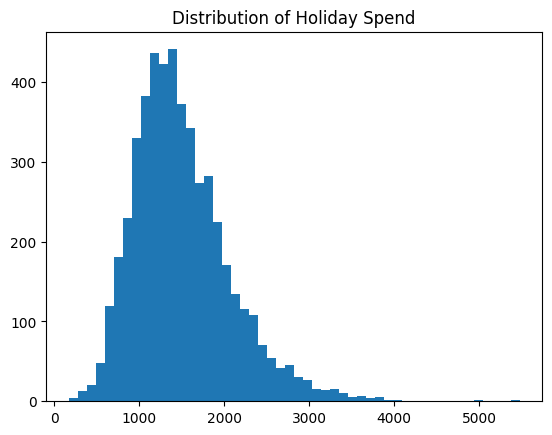

Skew: 0.9730081766087808


In [ ]:
# Cehcking the shape of the target variable's distribution
plt.hist(y, bins=50)
plt.title("Distribution of Holiday Spend")
plt.show()

print("Skew:", y.skew())

In [ ]:
print(f"\nTarget variable: {target}")
print(f"Features: {list(x.columns)}")

# Check target distribution
print(f"\nTarget Statistics:")
print(f"Mean: ${y.mean():,.2f}")
print(f"Std:  ${y.std():,.2f}")
print(f"Min:  ${y.min():,.2f}")
print(f"Max:  ${y.max():,.2f}")


Target variable: holiday_spend
Features: ['rolling_12mo_spend', 'rolling_12mo_visit', 'rolling_12mo_avg_basket', 'rolling_24mo_spend', 'pct_spend_grocery_consumables', 'pct_spend_pharmacy_health', 'pct_spend_home_hardware', 'pct_spend_auto_sporting', 'pct_spend_general_merch', 'member_tenure_years', 'return_rate', 'executive_flag', 'weekend_shopping_ratio', 'promo_usage_rate']

Target Statistics:
Mean: $1,501.20
Std:  $566.50
Min:  $171.04
Max:  $5,475.83


In [ ]:
# Applying Y transformation on the Target variable
y_log = np.log1p(y)

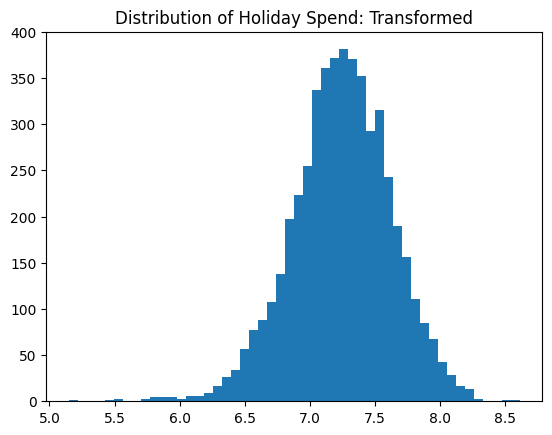

Skew: 0.9730081766087808


In [ ]:
# Cehcking the shape of the target variable's distribution
plt.hist(y_log, bins=50)
plt.title("Distribution of Holiday Spend: Transformed")
plt.show()

print("Skew:", y.skew())

## Checking for Multicollinearity

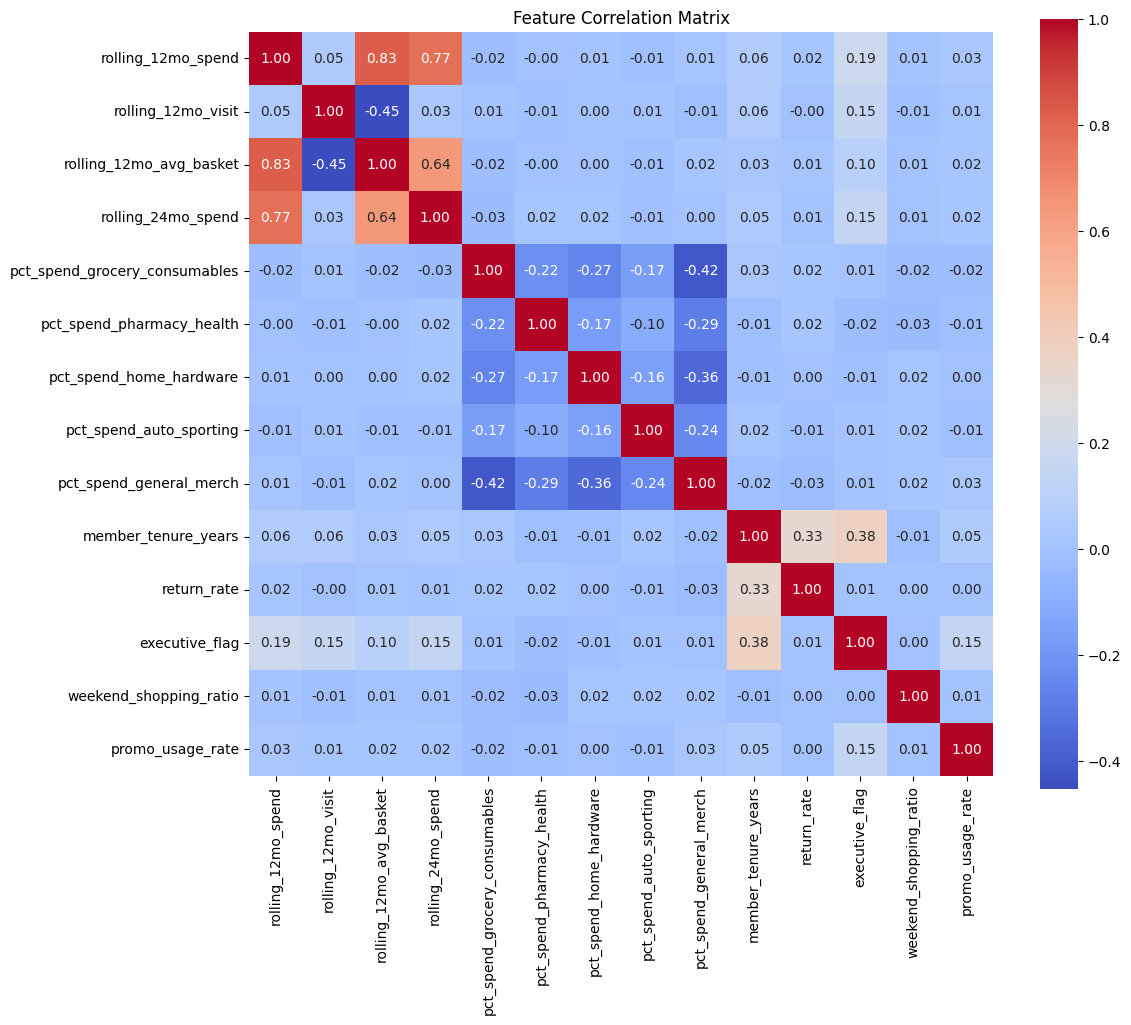

Highly correlated feature pairs (>|0.8|):
rolling_12mo_spend ↔ rolling_12mo_avg_basket : 0.83


In [ ]:
# Creating the correlation Matrix
corr_matrix = x.corr()

# Heatmap
plt.figure(figsize =(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Feature Correlation Matrix")
plt.show()

# List of highly correlated pairs
threshold = 0.8  # set a threshold for "high correlation"
high_corr = []

for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > threshold:
            high_corr.append(
                (corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j])
            )

print("Highly correlated feature pairs (>|0.8|):")
for f1, f2, val in high_corr:
    print(f"{f1} ↔ {f2} : {val:.2f}")

## Splitting the data

In [ ]:
print("\n" + "="*60)
print("DATA SPLITTING")
print("="*60)

# Train/Test split
x_train, x_test, y_train, y_test = train_test_split(
    x, y_log,
    test_size=0.2,
    random_state=42
    )
# Further split for validation
x_train_split, x_val, y_train_split, y_val = train_test_split(
    x_train, y_train,
    test_size=0.2,
    random_state=42
    )

print(f"Training set:       {x_train.shape[0]:,} samples")
print(f"  - For training:   {x_train_split.shape[0]:,} samples")
print(f"  - For validation: {x_val.shape[0]:,} samples")
print(f"Test set:           {x_test.shape[0]:,} samples")


DATA SPLITTING
Training set:       4,000 samples
  - For training:   3,200 samples
  - For validation: 800 samples
Test set:           1,000 samples


In [ ]:
# Creating a set without multicolinearity for linear models

print(f"\nFeature count:      {x_train.shape[1]} features")

correlated_feature = 'rolling_12mo_avg_basket'

x_train_clean = x_train.drop(columns=[correlated_feature])
x_test_clean = x_test.drop(columns=[correlated_feature])
x_train_split_clean = x_train_split.drop(columns=[correlated_feature])
x_val_clean = x_val.drop(columns=[correlated_feature])

print(f"\nClean feature count (linear models): {x_train_clean.shape[1]} features")
print(f"Removed feature: '{correlated_feature}'")


Feature count:      14 features

Clean feature count (linear models): 13 features
Removed feature: 'rolling_12mo_avg_basket'


In [ ]:
# Converting to DMatrix for XGBoost
print("\nCreating DMatrix objects for XGBoost...")
dtrain = xgb.DMatrix(x_train_split, label=y_train_split)
dval = xgb.DMatrix(x_val, label=y_val)
dtest = xgb.DMatrix(x_test, label=y_test)


Creating DMatrix objects for XGBoost...


# Model Training

## Linear Regression Model

In [ ]:
# Linear Regression Model
from sklearn.linear_model import LinearRegression

print("\nTraining Linear Regression...")
lr = LinearRegression()
lr.fit(x_train_split_clean, y_train_split)  # Train on log scale

# Predict and convert back to original scale
y_pred_lr_log = lr.predict(x_test_clean)
y_pred_lr = np.expm1(y_pred_lr_log)
y_test_actual = np.expm1(y_test)

# Calculate metrics
lr_r2 = r2_score(y_test_actual, y_pred_lr)
lr_mae = mean_absolute_error(y_test_actual, y_pred_lr)
lr_rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_lr))


Training Linear Regression...


## ElasticNet Regression

In [ ]:
# ElasticNet Regression
from sklearn.linear_model import ElasticNet

print("Training ElasticNet...")
enet = ElasticNet(alpha=0.001, l1_ratio=0.5, random_state=42)
enet.fit(x_train_split_clean, y_train_split)  # Train on log scale

# Predict and convert back
y_pred_enet_log = enet.predict(x_test_clean)
y_pred_enet = np.expm1(y_pred_enet_log)

# Calculate metrics
enet_r2 = r2_score(y_test_actual, y_pred_enet)
enet_mae = mean_absolute_error(y_test_actual, y_pred_enet)
enet_rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_enet))


Training ElasticNet...


## XGBoost

In [ ]:
print("Training XGBoost...")
# Setting the parameters
params = {
    "objective": "reg:squarederror",  # regression with squared error
    "max_depth": 3,
    "min_child_weight": 10,
    "eta": 0.03,                       # learning rate
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "alpha": 0.01,                     # L1 regularization
    "lambda": 0.1,                     # L2 regularization
    "eval_metric": "mae"               # monitoring metric
}

# Train with early stopping
evals = [(dtrain, "train"), (dval, "validation")]
bst = xgb.train(
    params,
    dtrain,
    num_boost_round=2000,
    evals=evals,
    early_stopping_rounds=10,
    verbose_eval=False
)

print(f"Best iteration: {bst.best_iteration}")

# Predict and convert back
y_pred_xgb_log = bst.predict(dtest)
y_pred_xgb = np.expm1(y_pred_xgb_log)

# Calculate metrics
xgb_r2 = r2_score(y_test_actual, y_pred_xgb)
xgb_mae = mean_absolute_error(y_test_actual, y_pred_xgb)
xgb_rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_xgb))

Training XGBoost...
Best iteration: 156


## General Performance (Model Error)

In [ ]:
print("\n" + "="*60)
print("MODEL COMPARISON (TEST SET PERFORMANCE)")
print("="*60)
print(f"{'Model':<20} {'R²':<10} {'MAE':<15} {'RMSE':<15}")
print("-"*60)

models_metrics = [
    ("Linear Regression", lr_r2, lr_mae, lr_rmse),
    ("ElasticNet", enet_r2, enet_mae, enet_rmse),
    ("XGBoost", xgb_r2, xgb_mae, xgb_rmse)
]

for name, r2, mae, rmse in models_metrics:
    print(f"{name:<20} {r2:.4f}     ${mae:,.2f}       ${rmse:,.2f}")

print("="*60)

# Find best model
best_model_idx = np.argmax([lr_r2, enet_r2, xgb_r2])
best_model_name = ["Linear Regression", "ElasticNet", "XGBoost"][best_model_idx]
print(f"\n🏆 Best Model: {best_model_name} (R² = {max(lr_r2, enet_r2, xgb_r2):.4f})")



MODEL COMPARISON (TEST SET PERFORMANCE)
Model                R²         MAE             RMSE           
------------------------------------------------------------
Linear Regression    0.6614     $264.66       $333.65
ElasticNet           0.6625     $264.42       $333.11
XGBoost              0.6864     $256.20       $321.07

🏆 Best Model: XGBoost (R² = 0.6864)


## Feature Importance

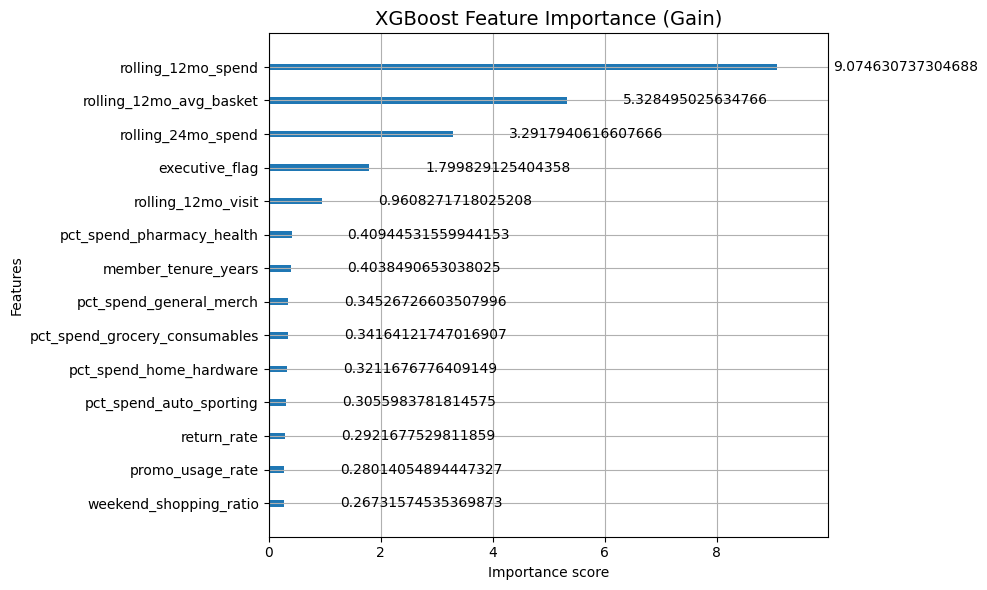

In [ ]:
plt.figure(figsize=(10, 6))
xgb.plot_importance(bst, ax=plt.gca(), importance_type='gain')
plt.title('XGBoost Feature Importance (Gain)', fontsize=14)
plt.tight_layout()
plt.show()


### SHAP

* SHAP is a way to help explain each prediction by showing how features push spending up or down.

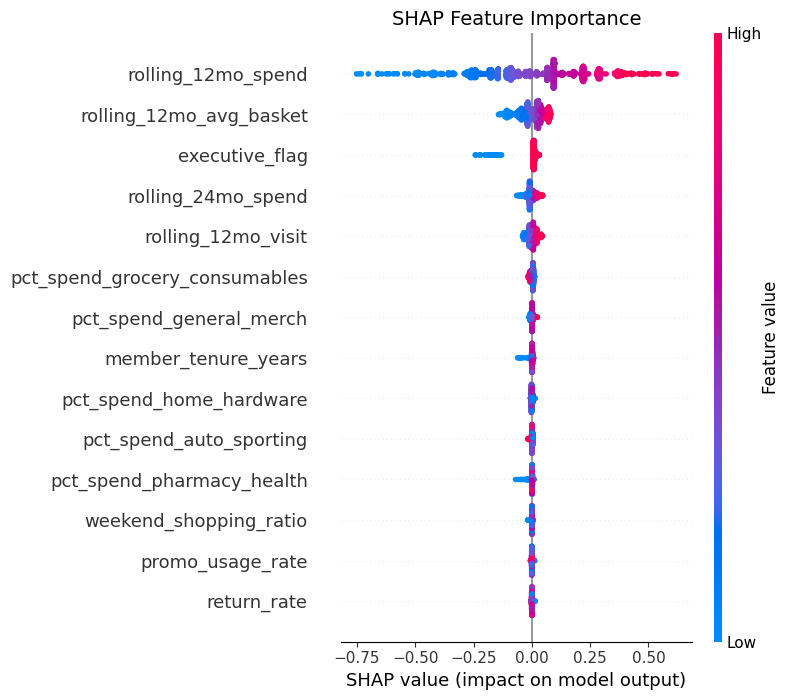

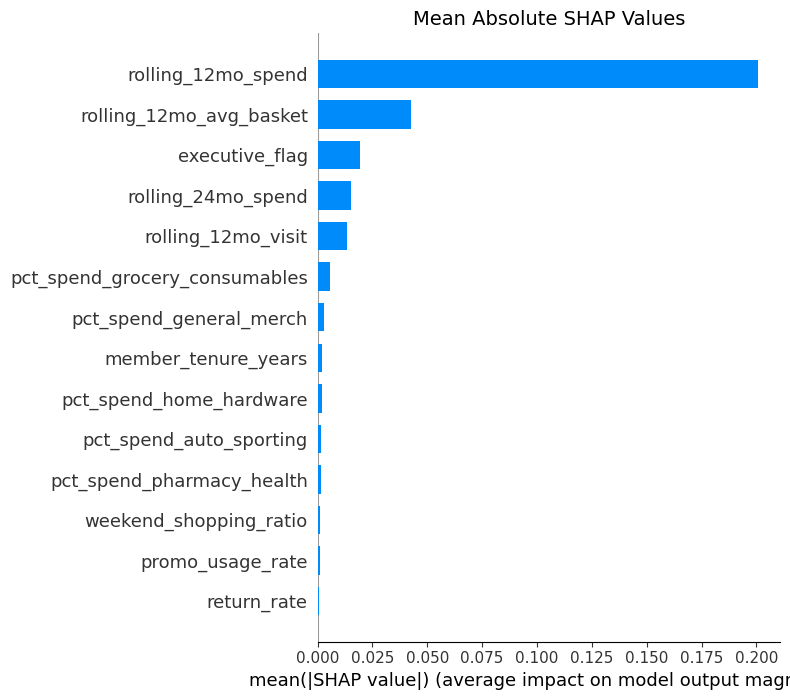

In [ ]:
# SHAP Explainer
explainer = shap.Explainer(bst)
shap_values = explainer(dtest)

# Summary plot
plt.figure(figsize=(12, 6))
shap.summary_plot(shap_values, x_test, show=False)
plt.title('SHAP Feature Importance', fontsize=14)
plt.tight_layout()
plt.show()

# SHAP summary bar plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, x_test, plot_type="bar", show=False)
plt.title('Mean Absolute SHAP Values', fontsize=14)
plt.tight_layout()
plt.show()

## Residual Analysis


RESIDUAL ANALYSIS


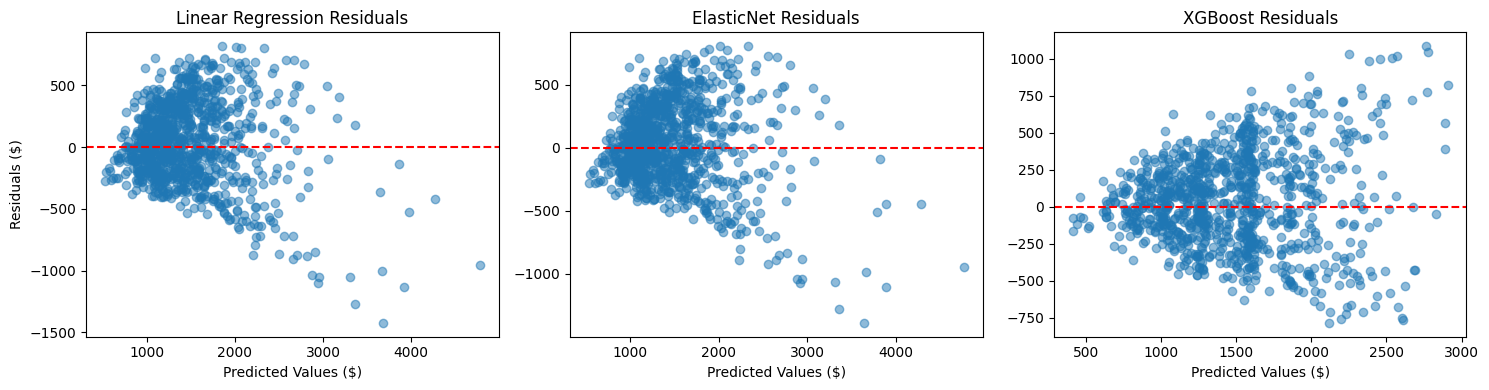

In [ ]:
print("\n" + "="*60)
print("RESIDUAL ANALYSIS")
print("="*60)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Linear Regression residuals
axes[0].scatter(y_pred_lr, y_test_actual - y_pred_lr, alpha=0.5)
axes[0].axhline(y=0, color='r', linestyle='--')
axes[0].set_xlabel('Predicted Values ($)')
axes[0].set_ylabel('Residuals ($)')
axes[0].set_title('Linear Regression Residuals')

# ElasticNet residuals
axes[1].scatter(y_pred_enet, y_test_actual - y_pred_enet, alpha=0.5)
axes[1].axhline(y=0, color='r', linestyle='--')
axes[1].set_xlabel('Predicted Values ($)')
axes[1].set_title('ElasticNet Residuals')

# XGBoost residuals
axes[2].scatter(y_pred_xgb, y_test_actual - y_pred_xgb, alpha=0.5)
axes[2].axhline(y=0, color='r', linestyle='--')
axes[2].set_xlabel('Predicted Values ($)')
axes[2].set_title('XGBoost Residuals')

plt.tight_layout()
plt.show()


## Individual Prediction Analysis

In [ ]:
print("\n" + "="*60)
print("INDIVIDUAL PREDICTION EXAMPLE")
print("="*60)

# Select a random test case
sample_idx = 0

# full set
sample_features_full = x_test.iloc[sample_idx]
# Clean set for linear models
sample_features_clean = x_test_clean.iloc[sample_idx]

actual_value = np.expm1(y_test.iloc[sample_idx])

# Get predictions from all models
lr_pred = np.expm1(lr.predict(sample_features_clean.to_frame().T)[0])
enet_pred = np.expm1(enet.predict(sample_features_clean.to_frame().T)[0])
xgb_pred = np.expm1(bst.predict(xgb.DMatrix(sample_features_full.to_frame().T))[0])

print(f"\nSample Member Features (full set):")
for feature, value in sample_features_full.items():
    print(f"  {feature}: {value: .4f}")

print(f"\nActual Holiday Spend: ${actual_value:,.2f}")
print(f"\nModel Predictions:")
print(f"  Linear Regression: ${lr_pred:,.2f} (Error: ${abs(actual_value - lr_pred):,.2f})")
print(f"  ElasticNet:        ${enet_pred:,.2f} (Error: ${abs(actual_value - enet_pred):,.2f})")
print(f"  XGBoost:           ${xgb_pred:,.2f} (Error: ${abs(actual_value - xgb_pred):,.2f})")

# Optional: Show which feature was removed for linear models
print(f"\nNote: Linear models used features without '{correlated_feature}'")


INDIVIDUAL PREDICTION EXAMPLE

Sample Member Features (full set):
  rolling_12mo_spend:  3582.7028
  rolling_12mo_visit:  24.0000
  rolling_12mo_avg_basket:  149.2793
  rolling_24mo_spend:  5408.5631
  pct_spend_grocery_consumables:  0.2828
  pct_spend_pharmacy_health:  0.1854
  pct_spend_home_hardware:  0.3070
  pct_spend_auto_sporting:  0.0473
  pct_spend_general_merch:  0.1774
  member_tenure_years:  13.3000
  return_rate:  0.0141
  executive_flag:  1.0000
  weekend_shopping_ratio:  0.5961
  promo_usage_rate:  0.1153

Actual Holiday Spend: $1,460.97

Model Predictions:
  Linear Regression: $1,158.06 (Error: $302.91)
  ElasticNet:        $1,151.33 (Error: $309.63)
  XGBoost:           $1,190.66 (Error: $270.31)

Note: Linear models used features without 'rolling_12mo_avg_basket'


# Summary and Recommendations

In [ ]:
print("\n" + "="*60)
print("SUMMARY AND RECOMMENDATIONS")
print("="*60)

print("\n1. DATA PREPARATION:")
print("   ✓ Applied log transformation to handle skewness")
print("   ✓ All models trained on consistent log-transformed scale")
print("   ✓ Proper train/validation/test splitting")
print("   ✓ Created separate feature sets for different model types")

print("\n2. CORRELATED FEATURES HANDLING:")
print(f"   ⚠️  Found highly correlated pair: rolling_12mo_spend ↔ rolling_12mo_avg_basket: 0.83")
print("   Implemented model-specific feature engineering:")
print("     ✓ XGBoost: Retained both features (robust to multicollinearity)")
print("     ✓ Linear/ElasticNet: Removed rolling_12mo_avg_basket (avoids coefficient instability)")

print("\n3. MODEL PERFORMANCE:")
print(f"   Best performing model: {best_model_name} (R² = {max(lr_r2, enet_r2, xgb_r2):.4f})")
print(f"   Linear Regression: R² = {lr_r2:.4f}, MAE = ${lr_mae:.2f}")
print(f"   ElasticNet:        R² = {enet_r2:.4f}, MAE = ${enet_mae:.2f}")
print(f"   XGBoost:           R² = {xgb_r2:.4f}, MAE = ${xgb_mae:.2f}")

print("\n4. KEY INSIGHTS:")
print("   ✓ Spending history (rolling_12mo_spend) is strongest predictor")
print("   ✓ Tree-based and linear models require different feature engineering")
print("   ✓ Residual patterns similar across models (no systematic bias)")
print("   ✓ Executive membership status significantly impacts spending")

print("\n5. RECOMMENDATIONS:")
print(f"   Production: Deploy {best_model_name} for holiday spend predictions")
print("   Feature engineering: Maintain separate preprocessing pipelines for:")
print("     - Tree models: Use all available features")
print("     - Linear models: Remove highly correlated features")
print("   Monitoring: Track model drift using MAE on validation data")
print("   Business: Focus on members with high annual spend for holiday campaigns")


SUMMARY AND RECOMMENDATIONS

1. DATA PREPARATION:
   ✓ Applied log transformation to handle skewness
   ✓ All models trained on consistent log-transformed scale
   ✓ Proper train/validation/test splitting
   ✓ Created separate feature sets for different model types

2. CORRELATED FEATURES HANDLING:
   ⚠️  Found highly correlated pair: rolling_12mo_spend ↔ rolling_12mo_avg_basket: 0.83
   Implemented model-specific feature engineering:
     ✓ XGBoost: Retained both features (robust to multicollinearity)
     ✓ Linear/ElasticNet: Removed rolling_12mo_avg_basket (avoids coefficient instability)

3. MODEL PERFORMANCE:
   Best performing model: XGBoost (R² = 0.6864)
   Linear Regression: R² = 0.6614, MAE = $264.66
   ElasticNet:        R² = 0.6625, MAE = $264.42
   XGBoost:           R² = 0.6864, MAE = $256.20

4. KEY INSIGHTS:
   ✓ Spending history (rolling_12mo_spend) is strongest predictor
   ✓ Tree-based and linear models require different feature engineering
   ✓ Residual patterns sim